# AGS Ejercicios
## Primera función

In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Valores de las variables
Nind = 100
Lind = 33
Pc = 0.9
Pm = 0.01
Maxgen = 1000
Nvar = 2
rango = np.array([[-3, 4.1], [12.1, 5.8]])

In [11]:
def creapob(Nind, Lind): 
    return np.random.randint(0, 2, size=(Nind, Lind))

In [12]:
def decodifica(genotipo, rango): 
    Nvar = rango.shape[1] 
    Nind, Lind = genotipo.shape 
    Lvar = Lind // Nvar 
    potencias = 2 ** np.arange(Lvar) 
 
    fenotipo = np.zeros((Nind, Nvar)) 
 
    for i in range(Nind): 
        for j in range(Nvar): 
            fenotipo[i, j] = np.sum(potencias * genotipo[i, (j * Lvar):(j * Lvar + Lvar)]) 
     
    for i in range(Nvar): 
        fenotipo[:, i] = rango[i, 0] + ((rango[i, 1] - rango[i, 0]) / (2 ** Lvar - 1)) * fenotipo[:, i] 
     
    return fenotipo

In [3]:
def objfun(fenotipo): 
    Nind, Nvar = fenotipo.shape 
    objv = np.zeros((Nind, 1)) 
     
    for i in range(Nind): 
        objv[i, 0] = 21.5 + fenotipo[i, 0] * np.sin(4 * np.pi * fenotipo[i, 0]) + fenotipo[i, 1] * np.sin(20 * np.pi * 
fenotipo[i, 1]) 
     
    return objv

In [4]:
def rankeo(objv, direccion): 
    SP = 2 
    Nind, Nobj = objv.shape 
    aptitud = np.zeros((Nind, 1)) 
     
    if direccion == 1: 
        nuevo_objv = np.sort(objv, axis=0) 
    else: 
        nuevo_objv = np.sort(-1 * objv, axis=0) 
     
    apt = 2 - SP + 2 * (SP - 1) * (np.arange(Nind) / (Nind - 1)) 
    posori = np.argsort(nuevo_objv, axis=0) 
     
    aptitud[posori, 0] = apt.reshape(-1, 1) 
     
    return aptitud

In [5]:
def ruleta(genotipo, fenotipo, aptitud): 
    Nind, aux = aptitud.shape 
    total = np.sum(aptitud) 
    probabilidad = aptitud / total 
    acumulada = np.cumsum(probabilidad) 
    idx = np.zeros((Nind, 1), dtype=int) 
     
    for i in range(Nind): 
        selecciona = np.random.rand() 
        aux = np.where(acumulada >= selecciona)[0] 
        idx[i, 0] = aux[0] 
     
    nuevo_gen = genotipo[idx.flatten(), :] 
     
    return nuevo_gen

In [6]:
def xunpunto(nuevo_gen, Pc): 
    Nind, Lind = nuevo_gen.shape 
    aux_gen = np.zeros((Nind, Lind)) 
    par = Nind % 2 
 
    for i in range(0, Nind - 1, 2): 
        cruza = np.random.rand() 
        if cruza <= Pc:
            corte = np.random.randint(0, Lind - 1) 
            aux_gen[i, :] = np.concatenate((nuevo_gen[i, :corte], nuevo_gen[i + 1, corte:])) 
            aux_gen[i + 1, :] = np.concatenate((nuevo_gen[i + 1, :corte], nuevo_gen[i, corte:])) 
        else: 
            aux_gen[i, :] = nuevo_gen[i, :] 
            aux_gen[i + 1, :] = nuevo_gen[i + 1, :] 
 
    if par == 1: 
        aux_gen[Nind - 1, :] = nuevo_gen[Nind - 1, :] 
 
    nuevo_gen = aux_gen 
     
    return nuevo_gen

In [7]:
def muta(nuevo_gen, Pm): 
    Nind, Lind = nuevo_gen.shape 
    valores = np.random.rand(Nind, Lind) 
    muta = valores <= Pm 
    nuevo_gen = np.logical_xor(nuevo_gen, muta) 
     
    return nuevo_gen

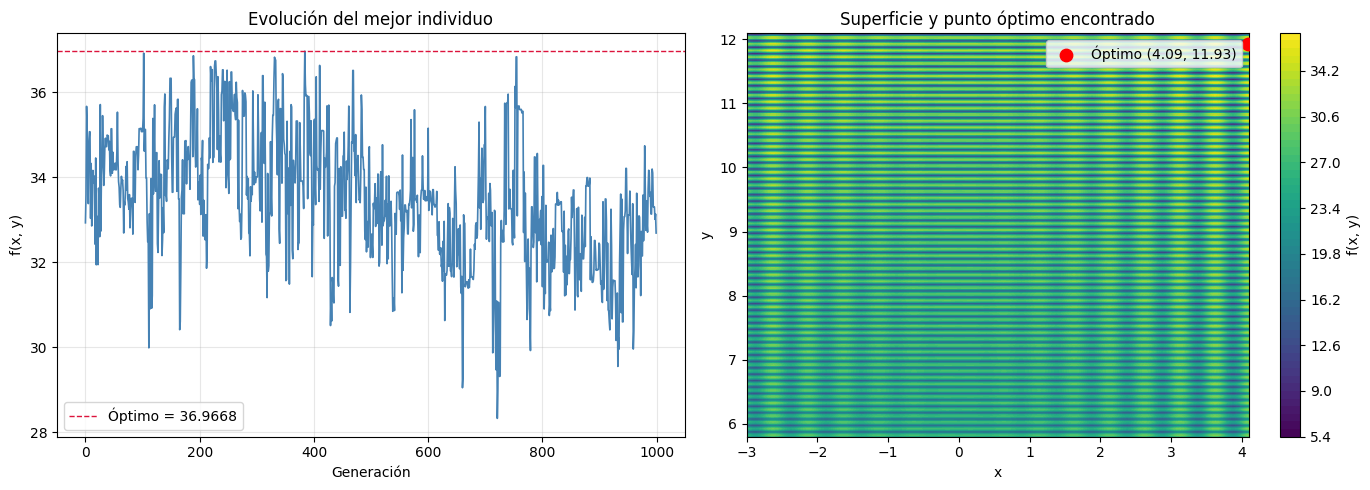

In [25]:
# Crear la poblacion inicial 
generaciones = 1000

genotipo = creapob(Nind, Lind)
Mejor = np.full((Maxgen, 1), np.nan)
Mejor_fenotipo = np.zeros((Maxgen, Nvar))

for gen in range(Maxgen):
    fenotipo = decodifica(genotipo, rango)
    objv     = objfun(fenotipo)
    aptitud  = rankeo(objv, 1)

    idx_mejor = np.argmax(objv)
    Mejor[gen] = objv[idx_mejor]
    Mejor_fenotipo[gen] = fenotipo[idx_mejor]

    nuevo_gen = ruleta(genotipo, fenotipo, aptitud)
    nuevo_gen = xunpunto(nuevo_gen, Pc)
    nuevo_gen = muta(nuevo_gen, Pm)
    genotipo  = nuevo_gen

# Grafica (AGS)
idx_global = np.nanargmax(Mejor)
x_opt = Mejor_fenotipo[idx_global, 0]
y_opt = Mejor_fenotipo[idx_global, 1]
f_opt = Mejor[idx_global, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(Mejor, color='steelblue', linewidth=1.2)
ax.axhline(f_opt, color='crimson', linestyle='--', linewidth=1, label=f'Óptimo = {f_opt:.4f}')
ax.set_xlabel('Generación')
ax.set_ylabel('f(x, y)')
ax.set_title('Evolución del mejor individuo')
ax.legend()
ax.grid(True, alpha=0.3)

x_range = np.linspace(-3, 4.1, 300)
y_range = np.linspace(12.1, 5.8, 300)
X, Y = np.meshgrid(x_range, y_range)
Z = 21.5 + X*np.sin(4*np.pi*X) + Y*np.sin(20*np.pi*Y)

ax2 = axes[1]
cp = ax2.contourf(X, Y, Z, levels=60, cmap='viridis')
fig.colorbar(cp, ax=ax2, label='f(x, y)')
ax2.scatter(x_opt, y_opt, color='red', s=80, zorder=5, label=f'Óptimo ({x_opt:.2f}, {y_opt:.2f})')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Superficie y punto óptimo encontrado')
ax2.legend()

plt.tight_layout()
plt.show()